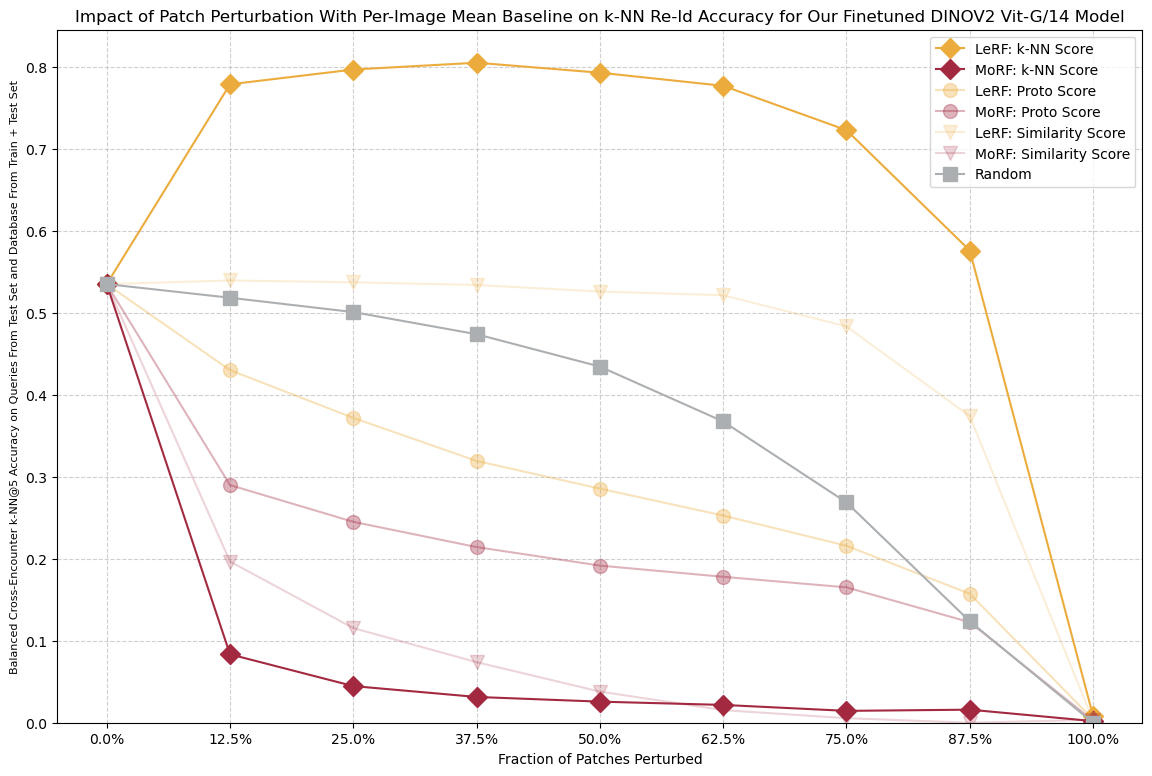

In [1]:
from collections import defaultdict
import matplotlib.pyplot as plt

hpi_red = (0.6352941176470588, 0.1607843137254902, 0.25098039215686274)
hpi_orange = (0.807843137254902, 0.40784313725490196, 0.17647058823529413)
hpi_yellow = (0.9254901960784314, 0.6745098039215687, 0.23921568627450981)
hpi_gray = (0.6745098039215687, 0.6862745098039216, 0.6980392156862745)

colors = {
    'MoRF': hpi_red,
    'LeRF': hpi_yellow,
    'random': hpi_gray,
}

transparencies = {
    'Similarity Score': 0.2,
    'k-NN Score': 1,
    'Proto Score': 0.35
}

markers = {
    'Similarity Score': 'v',    # Dreieck nach unten
    'k-NN Score': 'D',    # Diamond
    'Proto Score': 'o'   # Kreis
}
random_marker = 's'

plot_fractions = [0.0, 0.125, 0.25, 0.375, 0.5, 0.625, 0.75, 0.875, 1.0]

scores  = ['k-NN Score', 'Proto Score', 'Similarity Score'] # Auch knn-score mit topk hier reinnehmen? Vielleicht extra Erklärungsaufwand nicht wert, da nicht so gut
finetuned_results = defaultdict(lambda: defaultdict(list))
finetuned_results['Similarity Score']['MoRF'] = [0.5354129 , 0.19678792, 0.11551446, 0.07391675, 0.03799264,0.01537756, 0.00553827, 0.0, 0.00360026]
finetuned_results['Similarity Score']['LeRF'] = [0.5354129 , 0.5398435 , 0.5375913 , 0.53433865, 0.52631986,0.5217886 , 0.48377556, 0.37419996, 0.00248139]
finetuned_results['Similarity Score']['random'] = [0.5354129 , 0.51876765, 0.5012592 , 0.47422993, 0.4347181 ,0.3677056 , 0.26890856, 0.12381879, 0.0]

finetuned_results['k-NN Score']['MoRF'] = [0.5354129 , 0.08350542, 0.04470951, 0.03146149, 0.02572947, 0.02172784, 0.0144704 , 0.01593451, 0.00198511]
finetuned_results['k-NN Score']['LeRF'] = [0.5354129 , 0.77931285, 0.7973267 , 0.8056423 , 0.7934455 , 0.77746654, 0.7233125 , 0.576423 , 0.00843672]
finetuned_results['k-NN Score']['random'] = [0.5354129 , 0.51876765, 0.5012592 , 0.47422993, 0.4347181 , 0.3677056 , 0.26890856, 0.12381879, 0.0]

finetuned_results['k-NN Score TopK']['MoRF'] = [0.5354129 , 0.31286132, 0.29440698, 0.28703943, 0.26079234, 0.2133247 , 0.11239873, 0.08972684, 0.00148883]
finetuned_results['k-NN Score TopK']['LeRF'] = [0.5354129 , 0.59503436, 0.5764148 , 0.5559194 , 0.51918507,0.45084548, 0.31684625, 0.23200542, 0.00074442]
finetuned_results['k-NN Score TopK']['random'] = [0.5354129 , 0.51876765, 0.5012592 , 0.47422993, 0.4347181 ,0.3677056 , 0.26890856, 0.12381879, 0.0]

# Der "normale" knn-score gewichtet mit einem softmax *alle* embeddings der Datenbank danach, wie nah sie am query embedding sind. Die stärke der gewichtung wird durch einen
# temp parameter bestimmt, der mit 0.01 sehr klein ist. Es werden also nur die nähesten nachbarn stark gewichtet, alle anderen fast gar nicht. (wie viele das genau sind, ist nicht zu sagen)

# Der knn-score mit topk beschränkt die gewichtung auf die k-nächsten nachbarn (benutzt auch softmax + temp)
# Es sieht so aus, als ob je größer das k, desto besser die Ergbenisse (k=1, k=5 und k=50 getestet im sweep)


finetuned_results['Proto Score']['MoRF'] = [0.5354129 , 0.29007584, 0.24523287, 0.2143895 , 0.19180459, 0.17811523, 0.16524616, 0.12270041, 0.00248587]
finetuned_results['Proto Score']['LeRF'] = [0.5354129 , 0.4303517 , 0.37209338, 0.3195742 , 0.28575042, 0.25286797, 0.21601315, 0.15736297, 0.00421836]
finetuned_results['Proto Score']['random'] = [0.5354129 , 0.51876765, 0.5012592 , 0.47422993, 0.4347181 ,0.3677056 , 0.26890856, 0.12381879, 0.0]
plt.figure(figsize=(14, 9))


for score in scores:
    for mode in ['LeRF', 'MoRF']:
        plt.plot(plot_fractions, 
                    finetuned_results[score][mode], 
                    marker=markers[score],
                    markersize=10,
                    linestyle='-', 
                    alpha=transparencies[score],
                    label=mode + ': ' + score, 
                    color=colors.get(mode, 'black')
                )

plt.plot(plot_fractions,
         finetuned_results['k-NN Score']['random'],
         marker=random_marker,
         markersize=10,
         linestyle='-',
         color=colors['random'],
         label='Random')

plt.title(f'Impact of Patch Perturbation With Per-Image Mean Baseline on k-NN Re-Id Accuracy for Our Finetuned DINOV2 Vit-G/14 Model')
plt.xlabel('Fraction of Patches Perturbed')
plt.ylabel(f"Balanced Cross-Encounter k-NN@5 Accuracy on Queries From Test Set and Database From Train + Test Set", fontsize=8)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.ylim(bottom=0)
plt.xticks(plot_fractions, [f'{p*100:.1f}%' for p in plot_fractions])
plt.show()

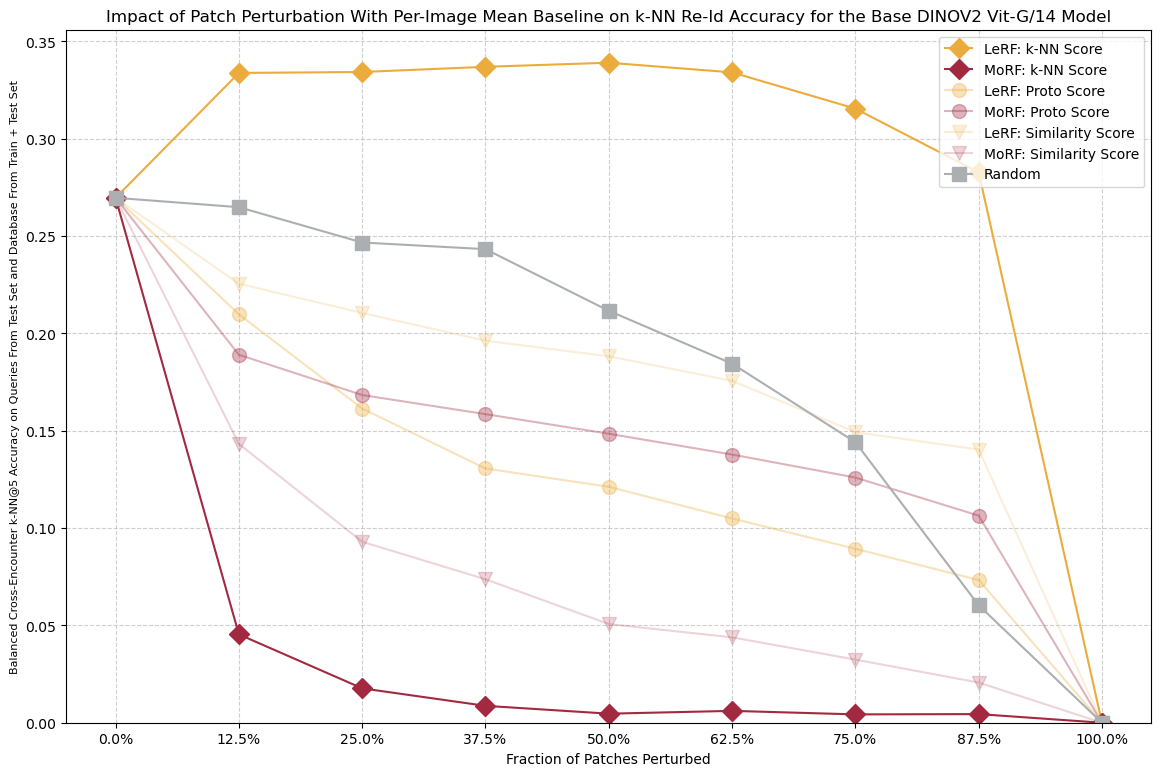

In [2]:
base_results = defaultdict(lambda: defaultdict(list))
base_results['Similarity Score']['MoRF'] = [0.26965812, 0.14323628, 0.09296378, 0.07369278, 0.05069256,0.04386841, 0.03243308, 0.02064186, 0.0]
base_results['Similarity Score']['LeRF'] = [0.26965812, 0.22551297, 0.21050549, 0.1962569 , 0.18821669,0.17565307, 0.14926156, 0.14035086, 0.0]
base_results['Similarity Score']['random'] = [0.26965812, 0.26484844, 0.24669567, 0.24328595, 0.21162449,0.18445395, 0.14412594, 0.06034802, 0.0]

base_results['k-NN Score']['MoRF'] = [0.26965812, 0.04537795, 0.01765733, 0.00867829, 0.00464466, 0.00609273, 0.00427612, 0.00442925, 0.0]
base_results['k-NN Score']['LeRF'] = [0.26965812, 0.3338096 , 0.33429617, 0.33696443, 0.33905625,0.33409137, 0.31546608, 0.28275743, 0.0]
base_results['k-NN Score']['random'] = [0.26965812, 0.26484844, 0.24669567, 0.24328595, 0.21162449,0.18445395, 0.14412594, 0.06034802, 0.0]

base_results['k-NN Score TopK']['MoRF'] = [0.26965812, 0.11141554, 0.11098647, 0.11589537, 0.1107739 , 0.09068026, 0.0626337 , 0.04954474, 0.0]
base_results['k-NN Score TopK']['LeRF'] = [0.26965812, 0.34894052, 0.33627394, 0.32478762, 0.30971014, 0.27559862, 0.21684167, 0.13675255, 0.0]
base_results['k-NN Score TopK']['random'] = [0.26965812, 0.26484844, 0.24669567, 0.24328595, 0.21162449,0.18445395, 0.14412594, 0.06034802, 0.0]

base_results['Proto Score']['MoRF'] = [0.26965812, 0.18903138, 0.16834725, 0.15852365, 0.14844826,0.13777982, 0.12594481, 0.10639401, 0.0]
base_results['Proto Score']['LeRF'] = [0.26965812, 0.20980094, 0.16141072, 0.1306057 , 0.12120345,0.10493507, 0.08936656, 0.07332128, 0.0]
base_results['Proto Score']['random'] = [0.26965812, 0.26484844, 0.24669567, 0.24328595, 0.21162449,0.18445395, 0.14412594, 0.06034802, 0.0]
plt.figure(figsize=(14, 9))


for score in scores:
    for mode in ['LeRF', 'MoRF']:
        plt.plot(plot_fractions, 
                    base_results[score][mode], 
                    marker=markers[score],
                    markersize=10,
                    linestyle='-', 
                    alpha=transparencies[score],
                    label=mode + ': ' + score, 
                    color=colors.get(mode, 'black')
                )

plt.plot(plot_fractions,
         base_results['k-NN Score']['random'],
         marker=random_marker,
         markersize=10,
         linestyle='-',
         color=colors['random'],
         label='Random')

plt.title(f'Impact of Patch Perturbation With Per-Image Mean Baseline on k-NN Re-Id Accuracy for the Base DINOV2 Vit-G/14 Model')
plt.xlabel('Fraction of Patches Perturbed')
plt.ylabel(f"Balanced Cross-Encounter k-NN@5 Accuracy on Queries From Test Set and Database From Train + Test Set", fontsize=8)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.ylim(bottom=0)
plt.xticks(plot_fractions, [f'{p*100:.1f}%' for p in plot_fractions])
plt.show()